In [1]:
import torch

print(f"GPU available:  {torch.cuda.is_available()}")
print(f"GPU name:       {torch.cuda.get_device_name(0)}")
print(f"GPU memory:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CUDA version:   {torch.version.cuda}")

GPU available:  True
GPU name:       Tesla T4
GPU memory:     15.6 GB
CUDA version:   12.8


In [2]:
!pip install unsloth trl transformers datasets peft accelerate bitsandbytes boto3 pyarrow -q
print("✅ All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6

In [3]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 512

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit   = True,
    dtype          = None,
)

print(f"✅ Model loaded")
print(f"   Model name:       Llama-3.2-3B-Instruct (4-bit quantized)")
print(f"   Max seq length:   {max_seq_length}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   GPU memory used:  {torch.cuda.memory_allocated() / 1e9:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.


✅ Model loaded
   Model name:       Llama-3.2-3B-Instruct (4-bit quantized)
   Max seq length:   512
   Total parameters: 1,803,463,680
   GPU memory used:  2.29 GB


In [ ]:
import os

os.environ["AWS_ACCESS_KEY_ID"] = ""
os.environ["AWS_SECRET_ACCESS_KEY"] = ""
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

In [8]:
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    lora_alpha     = 16,
    lora_dropout   = 0,
    bias           = "none",
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)

model.print_trainable_parameters()
print(f"\n✅ LoRA adapters attached")
print(f"   Rank (r):       16")
print(f"   Alpha:          16")
print(f"   Target modules: q, k, v, o, gate, up, down projections")
print(f"   Dropout:        0")

Unsloth: Already have LoRA adapters! We shall skip this step.


trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511

✅ LoRA adapters attached
   Rank (r):       16
   Alpha:          16
   Target modules: q, k, v, o, gate, up, down projections
   Dropout:        0


In [9]:
import boto3

BUCKET = "25tvtm-cisc886-bucket-cloud-project"
REGION = "us-east-1"

# Uses AWS credentials already configured in the environment / Colab secrets / aws configure.
# Do not hard-code AWS access keys in the notebook.
session = boto3.Session(region_name=REGION)
s3 = session.client("s3")

try:
    s3.head_bucket(Bucket=BUCKET)
    print("✅ Connected")
except Exception as e:
    print(f"❌ {e}")


✅ Connected


In [10]:
import pandas as pd
from io import BytesIO
from datasets import Dataset

BUCKET = '25tvtm-cisc886-bucket-cloud-project'
# s3 is already defined from your connection cell above

def load_parquet_sample(prefix, max_files=5):
    response = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix)
    files = [
        obj['Key'] for obj in response.get('Contents', [])
        if obj['Key'].endswith('.parquet')
    ][:max_files]

    dfs = []
    for key in files:
        obj = s3.get_object(Bucket=BUCKET, Key=key)
        dfs.append(pd.read_parquet(BytesIO(obj['Body'].read())))
        print(f"  Loaded {key.split('/')[-1]} — {len(dfs[-1]):,} rows")

    return pd.concat(dfs, ignore_index=True)

print("Loading training data...")
train_df = load_parquet_sample('processed/train/', max_files=5)

print("\nLoading validation data...")
val_df = load_parquet_sample('processed/val/', max_files=2)

print(f"\n{'='*40}")
print(f"✅ Data loaded")
print(f"   Train rows: {len(train_df):,}")
print(f"   Val rows:   {len(val_df):,}")

Loading training data...
  Loaded part-00000-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 136,895 rows
  Loaded part-00001-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 138,076 rows
  Loaded part-00002-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 149,068 rows
  Loaded part-00003-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 125,656 rows
  Loaded part-00004-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 133,154 rows

Loading validation data...
  Loaded part-00000-e6e0017e-da75-4bb3-84ac-b4851accfa3a-c000.snappy.parquet — 16,575 rows
  Loaded part-00001-e6e0017e-da75-4bb3-84ac-b4851accfa3a-c000.snappy.parquet — 16,535 rows

✅ Data loaded
   Train rows: 682,849
   Val rows:   33,110


In [11]:
def format_prompt(row):
    return {
        "text": f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a helpful beauty and personal care product assistant trained on Amazon reviews.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
{row['prompt']}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>
{row['response']}<|eot_id|>"""
    }

train_data = Dataset.from_pandas(train_df[['prompt', 'response']].dropna())
val_data   = Dataset.from_pandas(val_df[['prompt', 'response']].dropna())

train_data = train_data.map(format_prompt)
val_data   = val_data.map(format_prompt)

print(f"✅ Data formatted")
print(f"   Train samples: {len(train_data):,}")
print(f"   Val samples:   {len(val_data):,}")
print(f"\nSample formatted prompt (first 300 chars):")
print(train_data[0]['text'][:300])

Map:   0%|          | 0/682849 [00:00<?, ? examples/s]

Map:   0%|          | 0/33110 [00:00<?, ? examples/s]

✅ Data formatted
   Train samples: 682,849
   Val samples:   33,110

Sample formatted prompt (first 300 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a helpful beauty and personal care product assistant trained on Amazon reviews.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
A customer reviewed a beauty and personal care product with ID 0446581348 and gave it 5.0 out of 5 st


In [12]:
train_small = train_data.select(range(min(50000, len(train_data))))
val_small   = val_data.select(range(min(5000, len(val_data))))

print(f"✅ Dataset reduced")
print(f"   Train: {len(train_small):,} samples")
print(f"   Val:   {len(val_small):,} samples")


✅ Dataset reduced
   Train: 50,000 samples
   Val:   5,000 samples


In [13]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
import os
import torch._dynamo

os.environ["TORCHDYNAMO_DISABLE"] = "1"
torch._dynamo.config.disable = True

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def tokenize_fn(example):
    return tokenizer(
        example["text"],
        truncation=True,
        max_length=512,
        padding=False,
    )

print("Tokenizing train...")
train_tok = train_small.map(
    tokenize_fn,
    batched=True,
    remove_columns=train_small.column_names,
    num_proc=1,
)

print("Tokenizing val...")
val_tok = val_small.map(
    tokenize_fn,
    batched=True,
    remove_columns=val_small.column_names,
    num_proc=1,
)

collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

args = TrainingArguments(
    output_dir                  = "./outputs",
    max_steps                   = 200,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps                = 10,
    learning_rate               = 2e-4,
    fp16                        = True,
    bf16                        = False,
    logging_steps               = 10,
    eval_strategy               = "steps",
    eval_steps                  = 50,
    save_strategy               = "no",
    optim                       = "adamw_8bit",
    weight_decay                = 0.01,
    seed                        = 42,
    report_to                   = "none",
    dataloader_num_workers      = 0,
    torch_compile               = False,
)

trainer = Trainer(
    model         = model,
    args          = args,
    train_dataset = train_tok,
    eval_dataset  = val_tok,
    data_collator = collator,
)

print("✅ Trainer configured")
print(f"   Train: {len(train_tok):,} | Val: {len(val_tok):,}")
print("   Max steps: 200 | Batch size: 2 | Grad accum: 4")


Tokenizing train...


Map (num_proc=1):   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenizing val...


Map (num_proc=1):   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ Trainer configured
   Train: 50,000 | Val: 5,000
   Max steps: 200 | Batch size: 2 | Grad accum: 4


In [14]:
print("Starting training...")
print("=" * 50)

trainer_stats = trainer.train()

print("=" * 50)
print("✅ Training complete")
print(f"   Total steps:  {trainer_stats.global_step}")
print(f"   Final loss:   {trainer_stats.training_loss:.4f}")
print(f"   Total time:   {trainer_stats.metrics['train_runtime']:.0f} seconds")


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50,000 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Starting training...


`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,1.880921,1.837171
100,1.782020,1.726775
150,1.637044,1.584458
200,1.635866,1.580062


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✅ Training complete
   Total steps:  200
   Final loss:   1.9779
   Total time:   2385 seconds


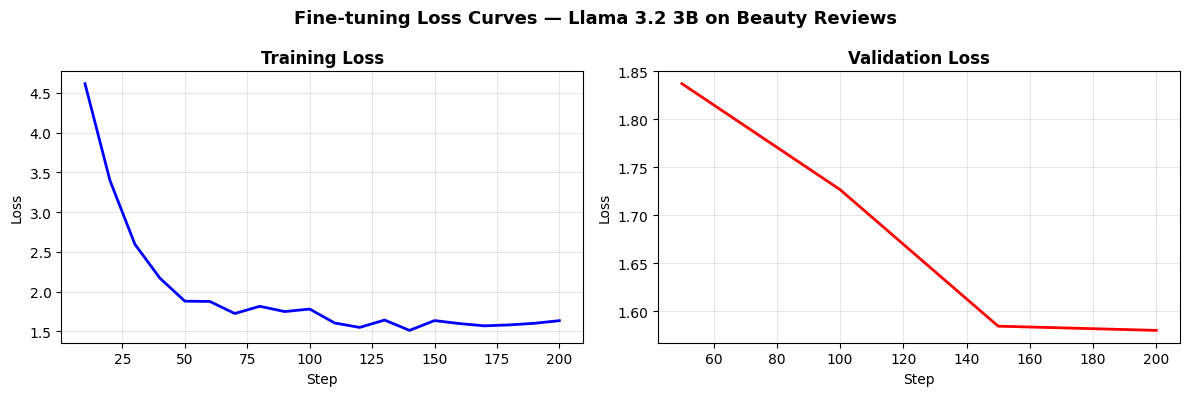

✅ Loss curve saved


In [15]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot([x['step'] for x in train_logs],
         [x['loss'] for x in train_logs], 'b-', linewidth=2)
ax1.set_title('Training Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot([x['step'] for x in eval_logs],
         [x['eval_loss'] for x in eval_logs], 'r-', linewidth=2)
ax2.set_title('Validation Loss', fontsize=12, fontweight='bold')
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

plt.suptitle('Fine-tuning Loss Curves — Llama 3.2 3B on Beauty Reviews',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve saved")

In [17]:
log_history = trainer.state.log_history
eval_logs   = [x for x in log_history if 'eval_loss' in x]

print("✅ Evaluation results from training:")
for entry in eval_logs:
    print(f"   Step {entry['step']:>3} — eval_loss: {entry['eval_loss']:.4f}")

final_eval = eval_logs[-1]
print(f"\n   Final eval loss:    {final_eval['eval_loss']:.4f}")
print(f"   Final eval runtime: {final_eval.get('eval_runtime', 'N/A')}")

✅ Evaluation results from training:
   Step  50 — eval_loss: 1.8372
   Step 100 — eval_loss: 1.7268
   Step 150 — eval_loss: 1.5845
   Step 200 — eval_loss: 1.5801
   Step 200 — eval_loss: 1.5801

   Final eval loss:    1.5801
   Final eval runtime: 478.2845


In [18]:
print("Saving model to GGUF format...")
model.save_pretrained_gguf(
    "cisc886-model",
    tokenizer,
    quantization_method="q4_k_m"
)

import os
gguf_files = [f for f in os.listdir('.') if f.endswith('.gguf')]
print(f"\n✅ GGUF files created:")
for f in gguf_files:
    size = os.path.getsize(f) / 1e9
    print(f"   {f}: {size:.2f} GB")

Saving model to GGUF format...
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in cisc886-model/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [06:42<00:00, 201.07s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [05:46<00:00, 173.39s/it]


Unsloth: Merge process complete. Saved to `/content/cisc886-model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['cisc886-model_gguf/Llama-3.2-3B-Instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['cisc886-model_gguf/Llama-3.2-3B-Instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model cisc886-model_gguf/Llama-3.2-3B-Instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to cisc886-model_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f cisc886-model_gguf/Modelfile

✅ GGUF files created:


In [21]:
import os, boto3

# Find the GGUF file inside the folder
gguf_dir = '/content/cisc886-model_gguf'
gguf_files = [f for f in os.listdir(gguf_dir) if f.endswith('.gguf')]
print(f"Found GGUF files: {gguf_files}")

gguf_path = os.path.join(gguf_dir, gguf_files[0])
file_size  = os.path.getsize(gguf_path) / 1e9
print(f"File: {gguf_path}")
print(f"Size: {file_size:.2f} GB")

Found GGUF files: ['Llama-3.2-3B-Instruct.Q4_K_M.gguf']
File: /content/cisc886-model_gguf/Llama-3.2-3B-Instruct.Q4_K_M.gguf
Size: 2.02 GB


In [22]:
import boto3, os

BUCKET    = '25tvtm-cisc886-bucket-cloud-project'
MODEL_KEY = 'model/cisc886-beauty-model.gguf'
gguf_path = '/content/cisc886-model_gguf/Llama-3.2-3B-Instruct.Q4_K_M.gguf'

s3 = boto3.Session(
    region_name='us-east-1'
).client('s3')

total    = os.path.getsize(gguf_path)
uploaded = [0]

def progress(chunk):
    uploaded[0] += chunk
    pct = uploaded[0] / total * 100
    print(f"\rUploading... {pct:.1f}% ({uploaded[0]/1e9:.2f}/{total/1e9:.2f} GB)", end='')

print(f"Uploading {total/1e9:.2f} GB to s3://{BUCKET}/{MODEL_KEY}")
s3.upload_file(gguf_path, BUCKET, MODEL_KEY, Callback=progress)
print(f"\n✅ Upload complete → s3://{BUCKET}/{MODEL_KEY}")

Uploading 2.02 GB to s3://25tvtm-cisc886-bucket-cloud-project/model/cisc886-beauty-model.gguf
Uploading... 100.0% (2.02/2.02 GB)
✅ Upload complete → s3://25tvtm-cisc886-bucket-cloud-project/model/cisc886-beauty-model.gguf
